# Image Stretching

## Histograms

Histograms are graphical representations of the pixel intensity distribution in an image. They provide insight into the tonal range of the image, including its brightness and contrast. A histogram with a narrow range of pixel intensities suggests low contrast, while a wider range indicates higher contrast.

Before we start with Stretching, let's understand what the histogram of an image is and how it can be used to analyze the image.

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_image, plot_histogram, plot_side_by_side

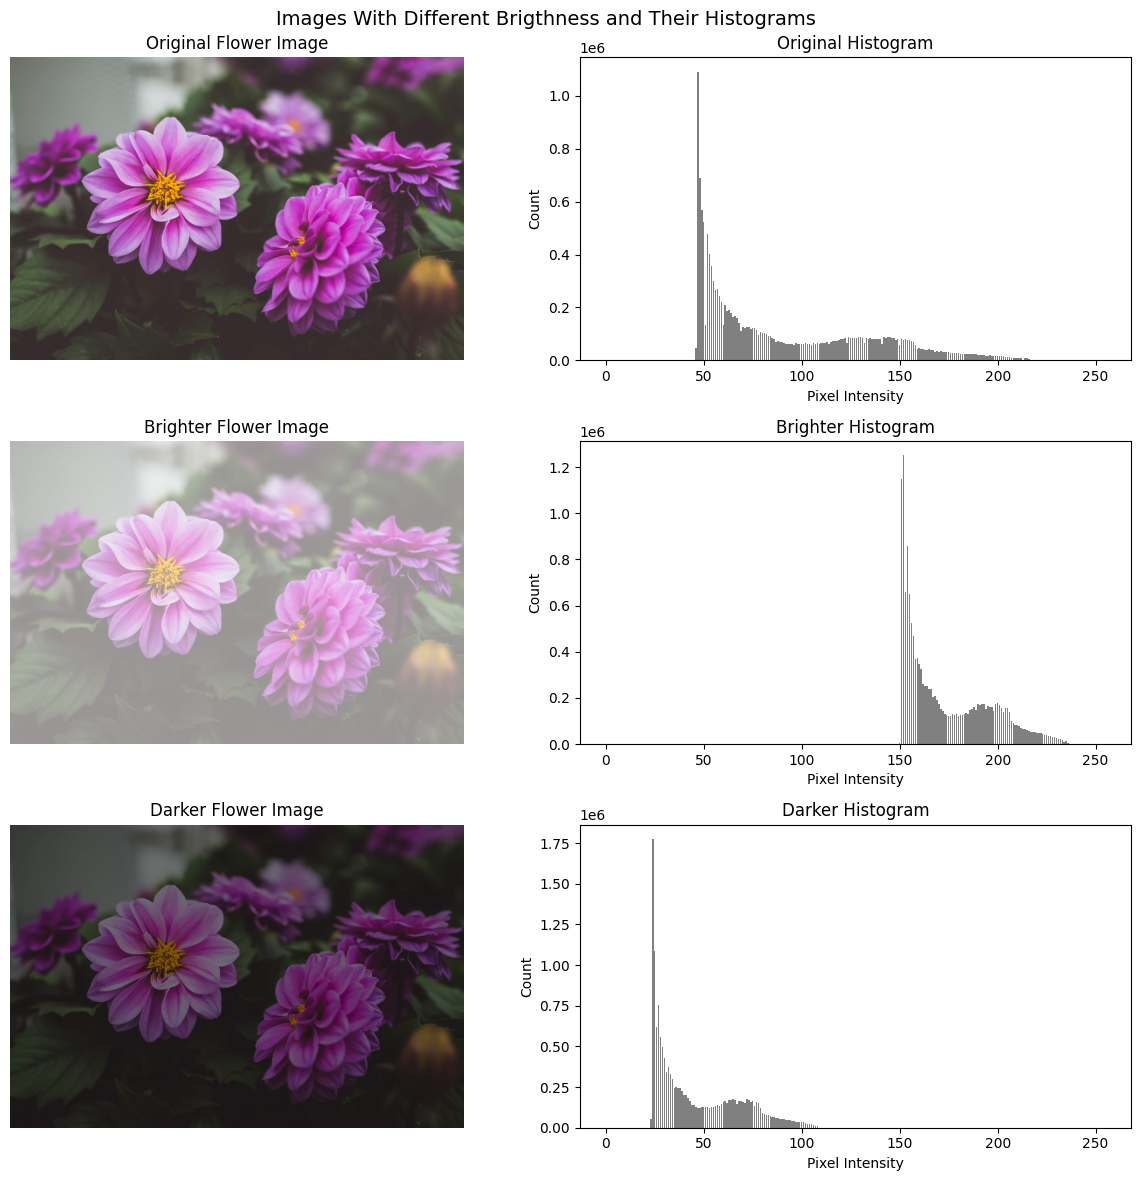

In [17]:
def read_image(path, is_gray=False):
    img = cv2.imread(path)
    if is_gray:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_flower_rgb = read_image('data/flower.jpg')
img_flower_darkened_rgb = read_image('data/flower_darkened.jpg')
img_flower_lightened_rgb = read_image('data/flower_lightened.jpg')
img_flower_gray = read_image('data/flower.jpg', is_gray=True)
img_flower_darkened_gray = read_image('data/flower_darkened.jpg', is_gray=True)
img_flower_lightened_gray = read_image('data/flower_lightened.jpg', is_gray=True)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
plt.suptitle('Images With Different Brigthness and Their Histograms', fontsize=14)

plot_image(axes[0, 0], img_flower_rgb, 'Original Flower Image', is_gray=True)
plot_histogram(axes[0, 1], img_flower_gray, 'Original Histogram', is_color=False)

plot_image(axes[1, 0], img_flower_lightened_rgb, 'Brighter Flower Image', is_gray=True)
plot_histogram(axes[1, 1], img_flower_lightened_gray, 'Brighter Histogram', is_color=False)

# Darker image
plot_image(axes[2, 0], img_flower_darkened_rgb, 'Darker Flower Image', is_gray=True)
plot_histogram(axes[2, 1], img_flower_darkened_gray, 'Darker Histogram', is_color=False)

plt.tight_layout()
plt.show()

As shown in the plots above, the histogram is useful for analyzing the distribution of pixel values in an image. If the histogram is more concentrated on the left, it indicates that there are more pixels with lower values, resulting in a darker image. On the other hand, if the histogram is shifted to the right, it reflects a brighter image due to a higher concentration of pixels with higher values.




## Analyzing an Astrophotography Image

Astrophotography images often have pixel intensities concentrated within a narrow range. Let's load and examine such an image.

libpng warning: iCCP: known incorrect sRGB profile


<Figure size 1200x800 with 0 Axes>

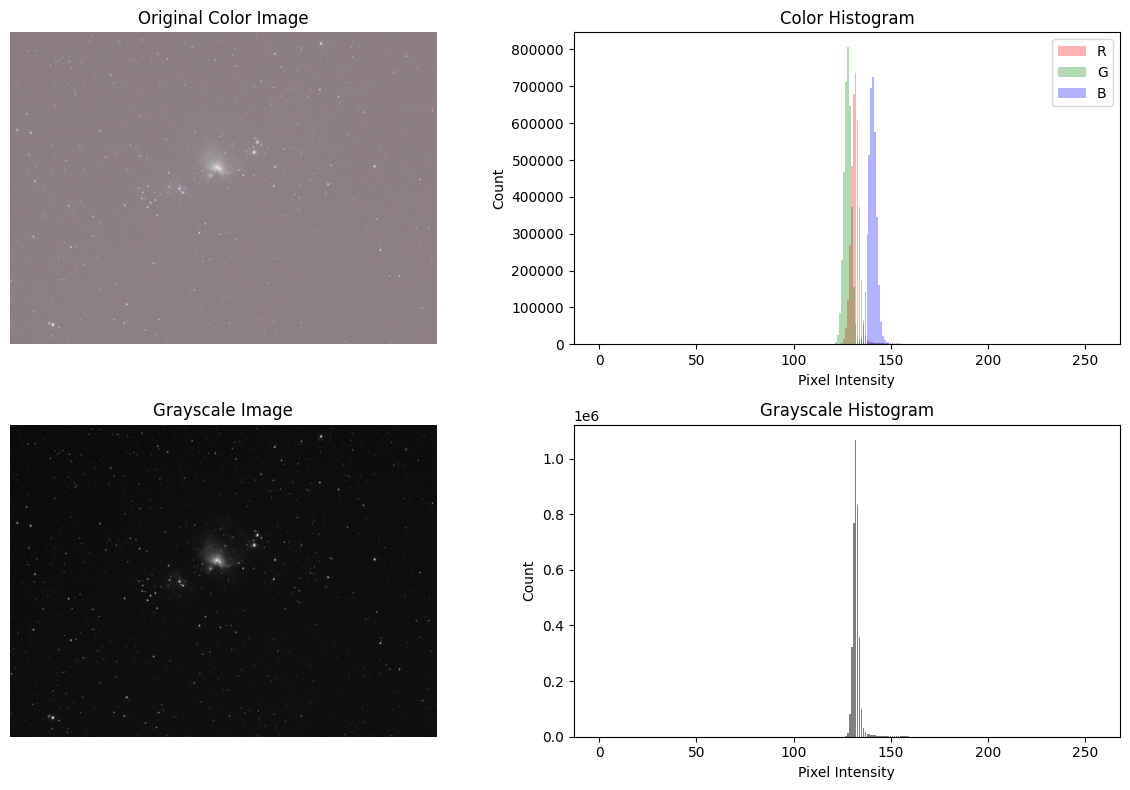

In [18]:
img = cv2.imread('images/orion.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 8))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_image(axes[0, 0], img_rgb, 'Original Color Image')
plot_histogram(axes[0, 1], img, 'Color Histogram')
plot_image(axes[1, 0], img_gray, 'Grayscale Image', is_gray=True)
plot_histogram(axes[1, 1], img_gray, 'Grayscale Histogram', is_color=False)

plt.tight_layout()
plt.show()

Notice that the pixel intensities in the histogram are concentrated on the left, within a very narrow range. This happens because the image is mostly dark, with only a few brighter areas. However, this narrow intensity range makes it difficult to see many details. 

To address this, a commonly used technique is to stretch the image across the full range of pixel intensities, enhancing visibility and revealing more details.

## Black Point Adjustment

One way to stretch an image is by adjusting the black point. This sets all values below a threshold to black, then stretches the remaining values across the full range. For example, with a threshold of 100, anything below 100 becomes black, and values from 100-255 are scaled to span the 0-255 range.

In astrophotography, black point adjustment is particularly useful because the darkest parts of the image often contain more noise than signal.

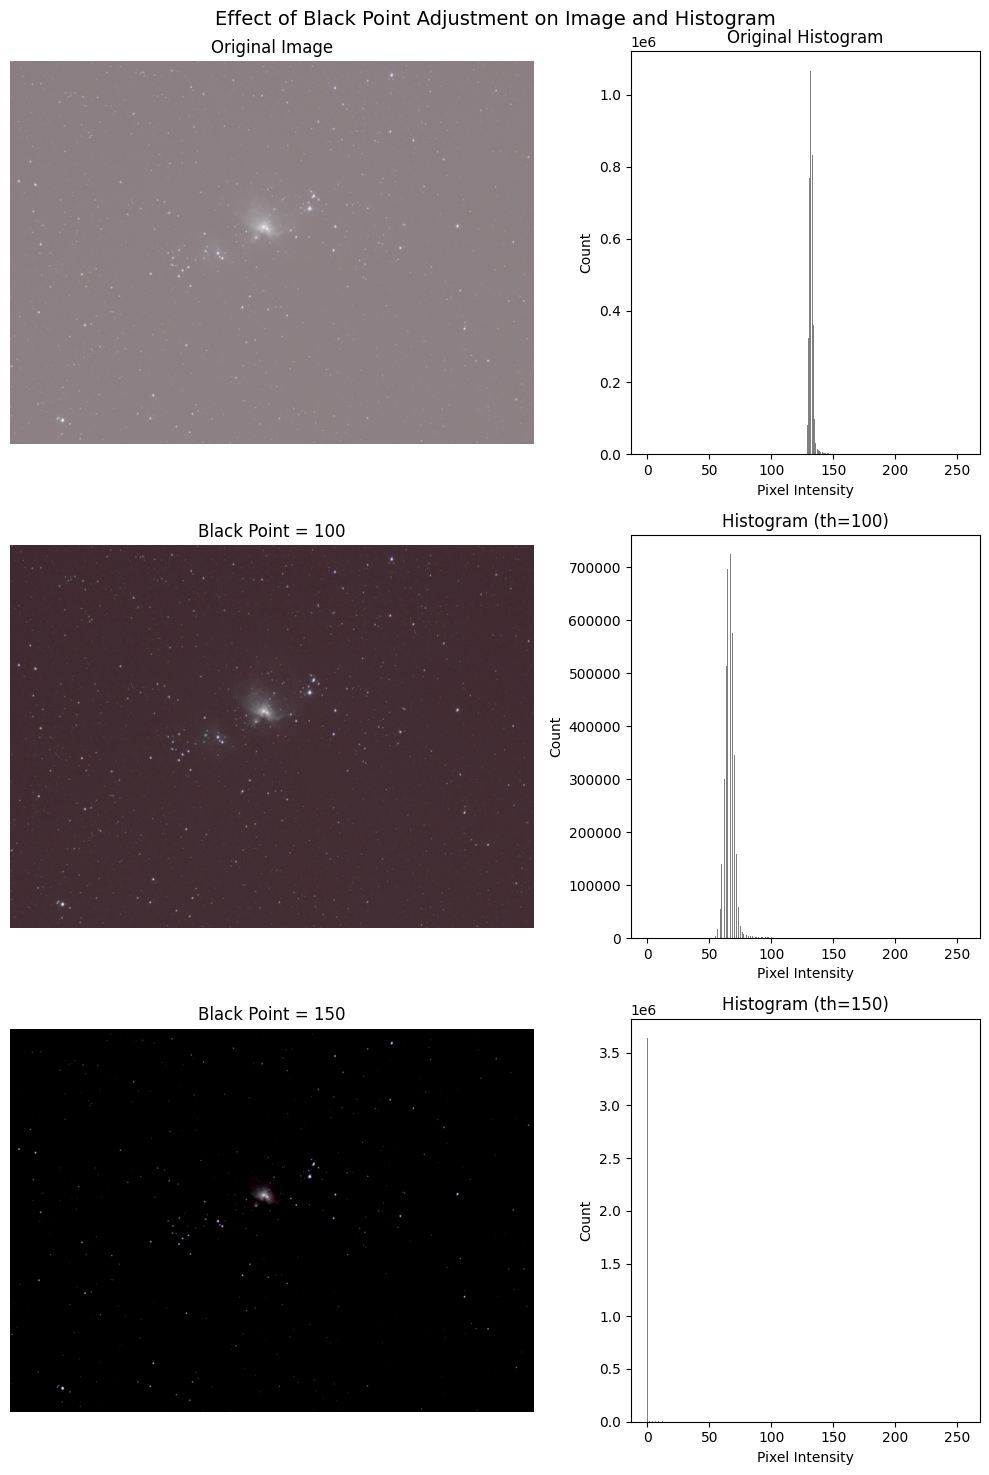

In [19]:
def adjust_black_point(img, threshold):
    """
    Adjusts image black point similar to Photoshop, making values below threshold
    black (0) and stretching remaining values across full range.
    """
    img_float = img.astype(float)
    mask = img_float >= threshold
    result = np.zeros_like(img_float)
    result[mask] = (img_float[mask] - threshold) * (255 / (255 - threshold))
    
    return np.clip(result, 0, 255).astype(np.uint8)

fig = plt.figure(figsize=(10, 15))
gs = fig.add_gridspec(3, 2, width_ratios=[1.5, 1])
axes = gs.subplots()
thresholds = [100, 150]

plot_image(axes[0, 0], img_rgb, 'Original Image', is_gray=True)
plot_histogram(axes[0, 1], img_gray, 'Original Histogram', is_color=False)

for idx, threshold in enumerate(thresholds, start=1):
    img_clipped = adjust_black_point(img_rgb, threshold)
    plot_image(axes[idx, 0], img_clipped, f'Black Point = {threshold}', is_gray=True)
    plot_histogram(axes[idx, 1], img_clipped, f'Histogram (th={threshold})', is_color=False)

plt.suptitle('Effect of Black Point Adjustment on Image and Histogram', fontsize=14)
plt.tight_layout()
plt.show()

Notice how a black point of 100 brings out lots of detail, but pushing it to 150 starts to clip important data.

## Mid Point Adjustment

Another approach is adjusting the midpoint. Normally, 128 is the middle gray in an image (halfway between 0 and 255). However, we can change that by setting another value as the midpoint, then the remaining intentsiy values can be either stretched or compressed depeding if the new mid point is bigger or smaller than 128. Midpoint adjuestment has also the advantage that it doesn't clip any data, it just reorganizes it.

The graphs below show how adjusting the midpoint affects pixel values. The gray diagonal line represents an unprocessed image where input equals output. Lowering the midpoint (e.g., to 64) compresses the darker values (below 128) and stretches the brighter ones (above 128), making the image brighter overall. Raising it (e.g., to 192) does the opposite, producing a darker image.

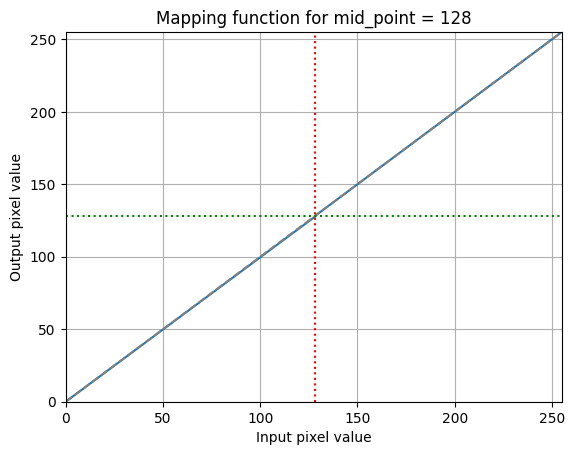

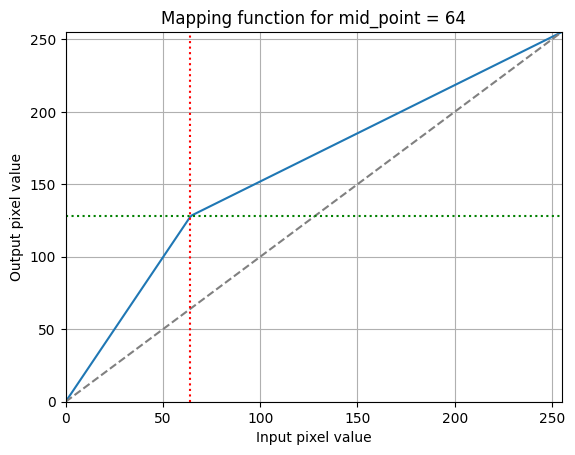

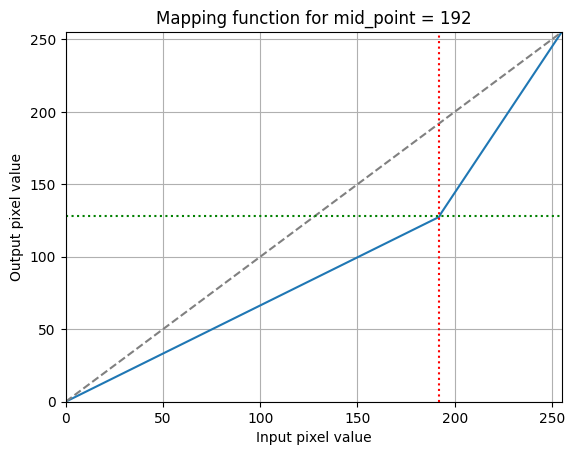

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mapping(mid_point):
    x = np.arange(256)
    y = np.where(x <= mid_point,
                 (x * 255) / (2 * mid_point),
                 128 + ((x - mid_point) * 127) / (255 - mid_point))
    
    plt.plot(x, y)
    plt.plot([0, 255], [0, 255], '--', color='gray')  # diagonal reference line
    plt.plot([mid_point, mid_point], [0, 255], ':', color='red')  # vertical mid_point line
    plt.plot([0, 255], [128, 128], ':', color='green')  # horizontal middle gray line
    plt.title(f'Mapping function for mid_point = {mid_point}')
    plt.xlabel('Input pixel value')
    plt.ylabel('Output pixel value')
    plt.xlim(0, 255)
    plt.ylim(0, 255)
    plt.grid(True)
    plt.show()

# Show mappings for different mid_points
for mid_point in [128, 64, 192]:
    plot_mapping(mid_point)

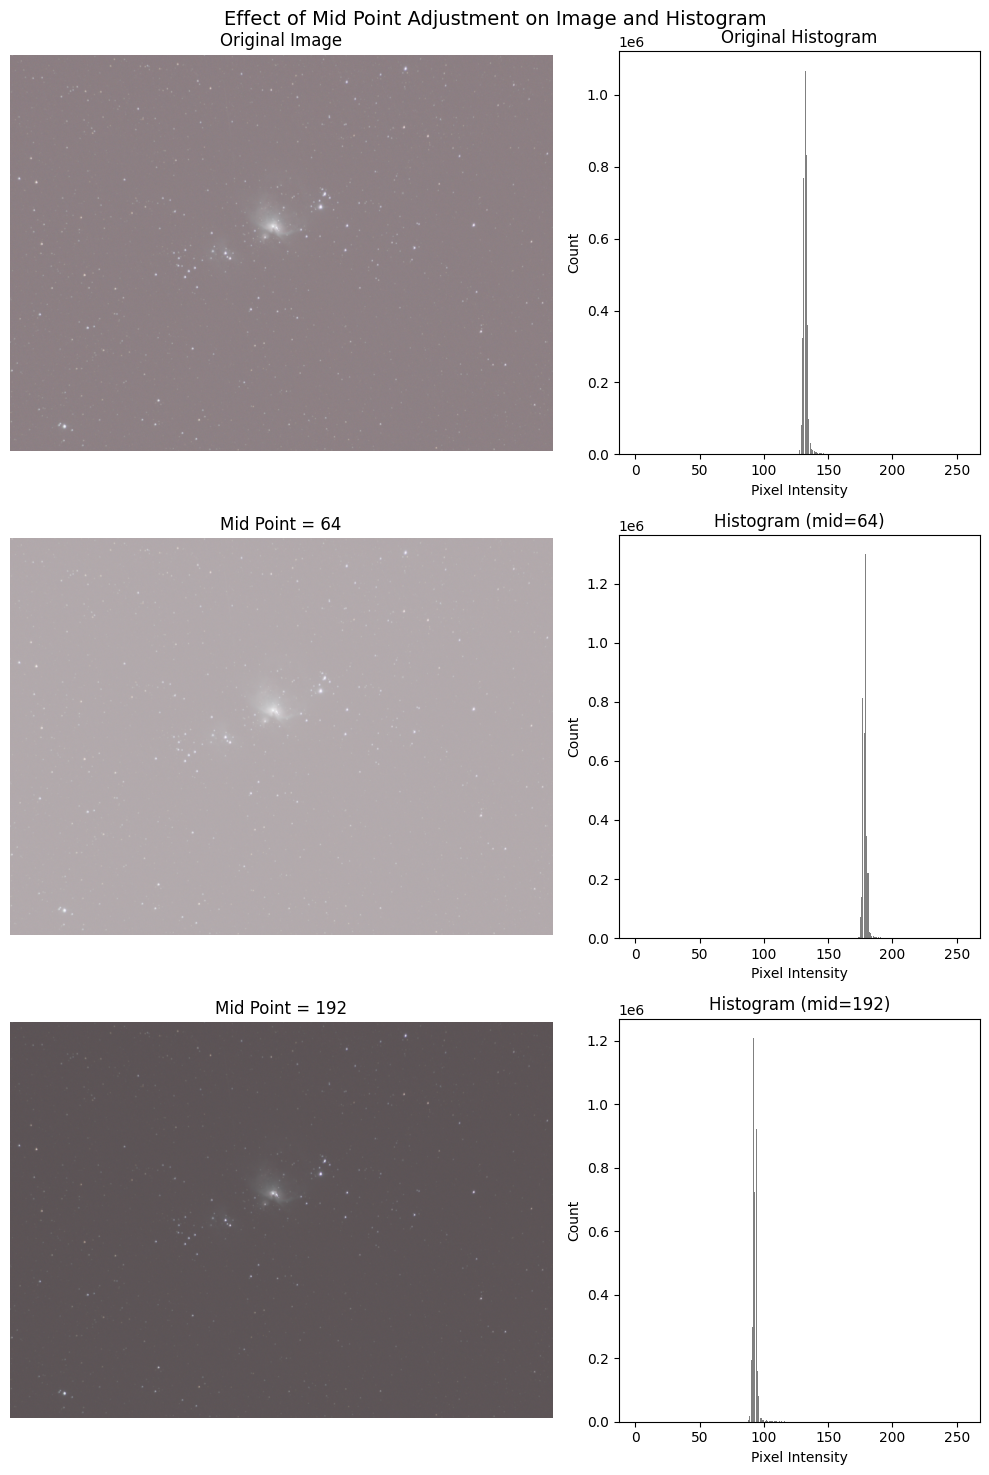

In [21]:
def adjust_mid_point(img, mid_point):
    """
    Adjusts image mid point similar to Photoshop's Levels adjustment.
    mid_point: value between 0 and 255
    - Lower values (< 128) make the image brighter
    - Higher values (> 128) make the image darker
    - At 128, there's no change
    """
    img_float = img.astype(float)
    
    x = np.arange(256)
    
    lut = np.where(x <= mid_point,
                   (x * 255) / (2 * mid_point),
                   128 + ((x - mid_point) * 127) / (255 - mid_point))
    
    result = np.interp(img_float, x, lut)
    
    return np.clip(result, 0, 255).astype(np.uint8)

fig = plt.figure(figsize=(10, 15))
gs = fig.add_gridspec(3, 2, width_ratios=[1.5, 1])
axes = gs.subplots()
mid_points = [64, 192]

plot_image(axes[0, 0], img_rgb, 'Original Image', is_gray=True)
plot_histogram(axes[0, 1], img_gray, 'Original Histogram', is_color=False)

for idx, mid_point in enumerate(mid_points, start=1):
    img_adjusted = adjust_mid_point(img_rgb, mid_point)
    plot_image(axes[idx, 0], img_adjusted, f'Mid Point = {mid_point}', is_gray=True)
    plot_histogram(axes[idx, 1], img_adjusted, f'Histogram (mid={mid_point})', is_color=False)

plt.suptitle('Effect of Mid Point Adjustment on Image and Histogram', fontsize=14)
plt.tight_layout()
plt.show()

## Combining Techniques

Now that we've seen both black point and midpoint adjustments in action, you might wonder about white point adjustment. However, in astrophotography, we actually want to avoid adjusting the white point. Here's why:
- Most of the interesting details in deep sky images are in the darker and mid-tone regions,
- The brightest parts (like star cores) should remain bright to preserve their natural appearance,
- White point adjustment can make stars look artificial by clipping their brightness,

Instead, the combination of black point and midpoint adjustments works better because:,
- Black point removes the noise floor in the darkest areas,
- Midpoint adjustment brings out the subtle nebulosity and dust lanes,
- Star cores and bright regions maintain their relative intensities"

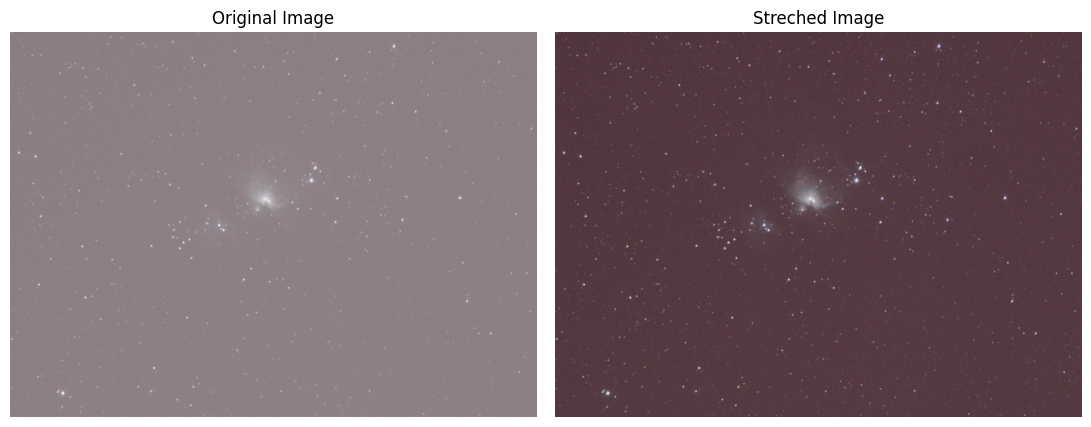

In [22]:

img_black_point_adj = adjust_black_point(img_rgb, 100)
img_mid_poin_adj = adjust_mid_point(img_black_point_adj, 100)

images = [img_rgb, img_mid_poin_adj]
titles = ["Original Image", "Streched Image"]
plot_side_by_side(images, titles, figsize=(14, 5))